# Can Satellites Predict Grain Prices?
## GRACE TWS as a Leading Indicator for Soybean Futures

**ETH Zurich - Space Data FS2026**

**Research question:** Do GRACE-derived terrestrial water storage (TWS) anomalies
over Brazil's central-southern agricultural belt **predict** soybean futures prices,
and what is the **temporal lag** between hydrological stress and market response?

**Causal chain hypothesis:**
```
GRACE TWS anomaly  ->  MODIS NDVI decline  ->  Soybean futures spike
   (drought signal)       (crop stress)          (supply shock)
```


## Setup


In [24]:
# Run once per Colab session (no-op when packages already present)
import subprocess, sys
# pkgs = ["xarray", "netCDF4", "earthengine-api>=0.1.370",
        # "yfinance", "statsmodels", "scikit-learn"]
# subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=False)


In [25]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.signal as sig
from scipy import stats
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgs
import os, pathlib, warnings, urllib.request
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

# ── USER CONFIG ─────────────────────────────────────────────────────────────
# Set paths to real data files.
GRACE_FILE  = "GRCTellus.JPL.200204_202512.GLO.RL06.3M.MSCNv04CRI.nc"
ERA5_FILE   = "era5_brazil_pet.nc"
NDVI_CSV    = "modis_ndvi_brazil_cropland.csv"
USE_GEE     = False          # True -> re-download NDVI via Earth Engine
GEE_PROJECT = "my-hello-world-472512"

FIG_DIR = pathlib.Path("figures"); FIG_DIR.mkdir(exist_ok=True)

LAT_MIN, LAT_MAX = -25.0, -8.0   # central-southern Brazil
LON_MIN, LON_MAX = -60.0, -46.0
T_START, T_END   = "2002-04", "2025-12"
GAP_START, GAP_END = "2017-07", "2018-05"   # GRACE / GRACE-FO transition gap
DROUGHT_YEARS    = [2005, 2010, 2015, 2021]
GROWING_MONTHS   = [10, 11, 12, 1, 2, 3]    # austral summer soy season

z = lambda s: (s - s.mean()) / s.std()       # z-score helper used in plots


## Helper Functions

All data-loading, statistical routines live in
`utils.py`. Import them here so the notebook cells focus on methodology and results.


In [26]:
from utils import (
    load_grace_mascons,
    load_era5, 
    get_ndvi_gee, 
    get_soybean_prices, 
    to_monthly, adf_test,
    cross_corr_bootstrap, rolling_corr_at_lag,
    partial_corr_at_lag, run_granger,
    drought_event_study, illustrative_backtest,
)
print("utils loaded.")


utils loaded.


## 1 · GRACE / GRACE-FO Terrestrial Water Storage

JPL RL06.3M v04 mascon solution -- 0.5 deg resolution, monthly, 2002-2025.
Study region: Mato Grosso / Goias / Parana (central-southern Brazil).


In [27]:

print("Loading real GRACE mascon file ...")
tws_region = load_grace_mascons(GRACE_FILE).sel(
    lat=slice(LAT_MIN, LAT_MAX), lon=slice(LON_MIN, LON_MAX),
    time=slice(T_START, T_END))
print(f"Shape : {tws_region.shape}")
print(f"Period: {str(tws_region.time.values[0])[:7]} -> {str(tws_region.time.values[-1])[:7]}")


Loading real GRACE mascon file ...
Shape : (252, 34, 28)
Period: 2002-04 -> 2025-12


In [28]:
# Area-weighted mean TWS time series + GRACE-FO gap check
# Note: JPL RL06M v04 fills the GRACE/GRACE-FO transition gap internally;
# gap_months=0 is expected and correct for this product.
lat_w    = np.cos(np.deg2rad(tws_region.lat.values))
w2d      = lat_w[:, np.newaxis] * np.ones(len(tws_region.lon))
tws_vals = tws_region.values          # (nt, nlat, nlon)

tws_mean = np.full(tws_vals.shape[0], np.nan)
for i in range(tws_vals.shape[0]):
    sl = tws_vals[i]; vld = ~np.isnan(sl)
    if vld.sum() > 0:
        tws_mean[i] = np.average(sl[vld], weights=w2d[vld])

times  = pd.DatetimeIndex(tws_region.time.values)
tws_ts = pd.Series(tws_mean, index=times, name="TWS_cm")

gap_flag      = tws_ts.isna()
gap_months    = tws_ts.index[gap_flag]
tws_ts_interp = tws_ts.interpolate(method="time")

print(f"Gap months ({len(gap_months)}): {list(gap_months.strftime('%Y-%m'))}")
print(f"TWS: mean={tws_ts_interp.mean():.2f} cm  std={tws_ts_interp.std():.2f} cm")


Gap months (0): []
TWS: mean=-3.35 cm  std=13.72 cm


In [29]:
# EOF / PCA -> GRACE Drought Index (PC1)
nt, nlat, nlon = tws_vals.shape
X_flat  = tws_vals.reshape(nt, nlat*nlon)
X_fill  = pd.DataFrame(X_flat).interpolate(method="linear", axis=0).values
vcols   = ~np.isnan(X_fill).any(axis=0)

scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_fill[:, vcols])
pca     = PCA(n_components=min(10, X_sc.shape[1], X_sc.shape[0]))
PCs     = pca.fit_transform(X_sc)
explained = pca.explained_variance_ratio_ * 100

print("Explained variance (EOF1-5):")
for i, ev in enumerate(explained[:5]):
    print(f"  EOF{i+1}: {ev:.1f}%")

PC1 = pd.Series(PCs[:,0], index=times, name="PC1_TWS")
if PC1.corr(tws_ts_interp) < 0:
    PC1 = -PC1   # convention: positive PC1 = wet anomaly

eof1_full = np.full(nlat*nlon, np.nan)
eof1_full[vcols] = pca.components_[0]
eof1_map  = eof1_full.reshape(nlat, nlon)
eof_lats  = tws_region.lat.values
eof_lons  = tws_region.lon.values


Explained variance (EOF1-5):
  EOF1: 58.5%
  EOF2: 19.9%
  EOF3: 9.9%
  EOF4: 4.1%
  EOF5: 1.6%


## 2 · ERA5-Land P - ET

Precipitation minus evapotranspiration: the atmospheric forcing driving TWS changes.


In [30]:
print("Loading ERA5-Land file ...")
pet_series = load_era5(ERA5_FILE)
pet_series.index = pd.DatetimeIndex(pet_series.index).to_period("M").to_timestamp()
pet_series = pet_series.loc[T_START:T_END]
print(f"P-ET series: {len(pet_series)} months")


Loading ERA5-Land file ...
P-ET series: 285 months


## 3 · MODIS NDVI -- Cropland Canopy Stress

MOD13A3 v061, cropland-masked (IGBP classes 12 & 14). Monthly composite NDVI.
Growing-season anomaly (monthly climatology removed) isolates drought stress.


In [31]:
if USE_GEE:
    print("Fetching NDVI from Google Earth Engine ...")
    ndvi_df = get_ndvi_gee(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, gee_project=GEE_PROJECT)
    ndvi_df.to_csv(NDVI_CSV)
elif NDVI_CSV and os.path.exists(NDVI_CSV):
    print("Loading NDVI from local CSV ...")
    ndvi_df = pd.read_csv(NDVI_CSV, index_col=0, parse_dates=True)


ndvi_df.index = pd.DatetimeIndex(ndvi_df.index).to_period("M").to_timestamp()
ndvi_series   = ndvi_df["NDVI"].loc[T_START:T_END]

ndvi_clim = ndvi_series.groupby(ndvi_series.index.month).mean()
ndvi_anom  = ndvi_series - ndvi_series.index.map(lambda d: ndvi_clim[d.month])
ndvi_anom.name = "NDVI_anom"
print(f"NDVI: mean={ndvi_series.mean():.3f}  std={ndvi_series.std():.3f}")


Loading NDVI from local CSV ...
NDVI: mean=0.589  std=0.133


## 4 · CBOT Soybean Futures (ZS=F)

Monthly close price downloaded from Yahoo Finance. Log-returns used for stationarity.


In [32]:
soy_price = get_soybean_prices(start=T_START[:4]+"-01-01", end="2026-01-01")


soy_price.index = soy_price.index.to_period("M").to_timestamp()
soy_price    = soy_price.loc[T_START:T_END]
soy_logret   = np.log(soy_price).diff().dropna()
soy_logret.name = "Soy_logret"
print(f"Soybean price : {soy_price.min():.0f} - {soy_price.max():.0f}  (n={len(soy_price)})")
print(f"Log-return std: {soy_logret.std():.4f}")


yfinance: 247 months of ZS=F prices.
Soybean price : 462 - 1764  (n=244)
Log-return std: 0.0818


## 5 · ENSO Index (ONI)

Oceanic Nino Index (3-month running mean Nino 3.4 SSTA) from NOAA CPC.
Used to partial-out ENSO as a confounder in the TWS -> Soy correlation.


In [33]:
ONI_URL = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"
S2M = {"DJF":1,"JFM":2,"FMA":3,"MAM":4,"AMJ":5,"MJJ":6,
       "JJA":7,"JAS":8,"ASO":9,"SON":10,"OND":11,"NDJ":12}

with urllib.request.urlopen(ONI_URL, timeout=20) as r:
    raw = r.read().decode("utf-8")
rows = []
for line in raw.strip().split("
"):
    parts = line.split()
    if len(parts) >= 4 and parts[0] in S2M:
        rows.append({"year": int(parts[1]), "month": S2M[parts[0]],
                     "ONI": float(parts[3])})
oni_df = pd.DataFrame(rows)
oni_df["date"] = pd.to_datetime(oni_df[["year","month"]].assign(day=1))
oni_series = oni_df.set_index("date")["ONI"].sort_index()
print(f"ONI downloaded: {len(oni_series)} months")

ONI downloaded: 913 months


## 6 · Master DataFrame

Align all series to a common monthly index. First-difference TWS and NDVI anomaly
to achieve stationarity (confirmed by ADF tests in the next section).


In [34]:
df = pd.DataFrame({
    "TWS_cm"    : to_monthly(tws_ts_interp),
    "PC1_TWS"   : to_monthly(PC1),
    "P_minus_ET": to_monthly(pet_series),
    "NDVI"      : to_monthly(ndvi_series),
    "NDVI_anom" : to_monthly(ndvi_anom),
    "Soybean"   : to_monthly(soy_price, agg="last"),
    "Soy_logret": to_monthly(soy_logret),
    "ONI"       : to_monthly(oni_series.loc[T_START:T_END]),
    "Gap_interp": to_monthly(gap_flag.astype(float).rename("Gap_interp"), agg="last"),
}).dropna(subset=["TWS_cm", "Soybean"])

df["dTWS"]  = df["TWS_cm"].diff()
df["dPC1"]  = df["PC1_TWS"].diff()
df["dPET"]  = df["P_minus_ET"].diff()
df["dNDVI"] = df["NDVI_anom"].diff()

print(f"Master DataFrame: {len(df)} months  "
      f"({df.index[0].strftime('%Y-%m')} - {df.index[-1].strftime('%Y-%m')})")
print(f"Gap months flagged: {int(df.Gap_interp.sum())}")
print()
print(df[["TWS_cm","NDVI","ONI","Soybean","Soy_logret"]].describe().round(3))


Master DataFrame: 214 months  (2002-04 - 2025-12)
Gap months flagged: 0

        TWS_cm     NDVI      ONI   Soybean  Soy_logret
count  214.000  214.000  214.000   214.000     213.000
mean    -3.517    0.589    0.037  1043.141       0.003
std     13.794    0.131    0.833   315.154       0.084
min    -33.136    0.332   -1.640   462.250      -0.398
25%    -14.553    0.479   -0.550   854.000      -0.039
50%     -4.260    0.620   -0.025  1005.875       0.010
75%      8.414    0.710    0.540  1310.562       0.051
max     26.104    0.814    2.750  1764.500       0.225


## 7 · Stationarity Tests (ADF)

Correlation and Granger tests require stationary series. We verify that level
series have a unit root and that first differences are stationary.


In [35]:
print("ADF Stationarity Tests  (H0: unit root)")
print("-"*65)
adf_test(df["TWS_cm"],     "TWS_cm (level)")
adf_test(df["dTWS"],       "dTWS (1st diff)")
adf_test(df["NDVI_anom"],  "NDVI anomaly")
adf_test(df["dNDVI"],      "dNDVI anomaly")
adf_test(df["Soybean"],    "Soybean price (level)")
adf_test(df["Soy_logret"], "Soy log-return")
adf_test(df["P_minus_ET"], "P-ET (level)")
adf_test(df["dPET"],       "dPET")
print()
print("-> Use dTWS and Soy log-return for all correlation / Granger tests.")


ADF Stationarity Tests  (H0: unit root)
-----------------------------------------------------------------
  TWS_cm (level)                ADF= -1.483  p=0.5418  [non-stationary]
  dTWS (1st diff)               ADF=-10.666  p=0.0000  [STATIONARY]
  NDVI anomaly                  ADF= -3.322  p=0.0139  [STATIONARY]
  dNDVI anomaly                 ADF= -9.065  p=0.0000  [STATIONARY]
  Soybean price (level)         ADF= -2.622  p=0.0885  [non-stationary]
  Soy log-return                ADF=-14.157  p=0.0000  [STATIONARY]
  P-ET (level)                  ADF= -2.707  p=0.0729  [non-stationary]
  dPET                          ADF=-10.177  p=0.0000  [STATIONARY]

-> Use dTWS and Soy log-return for all correlation / Granger tests.


## 8 · Exploratory Time-Series Overview


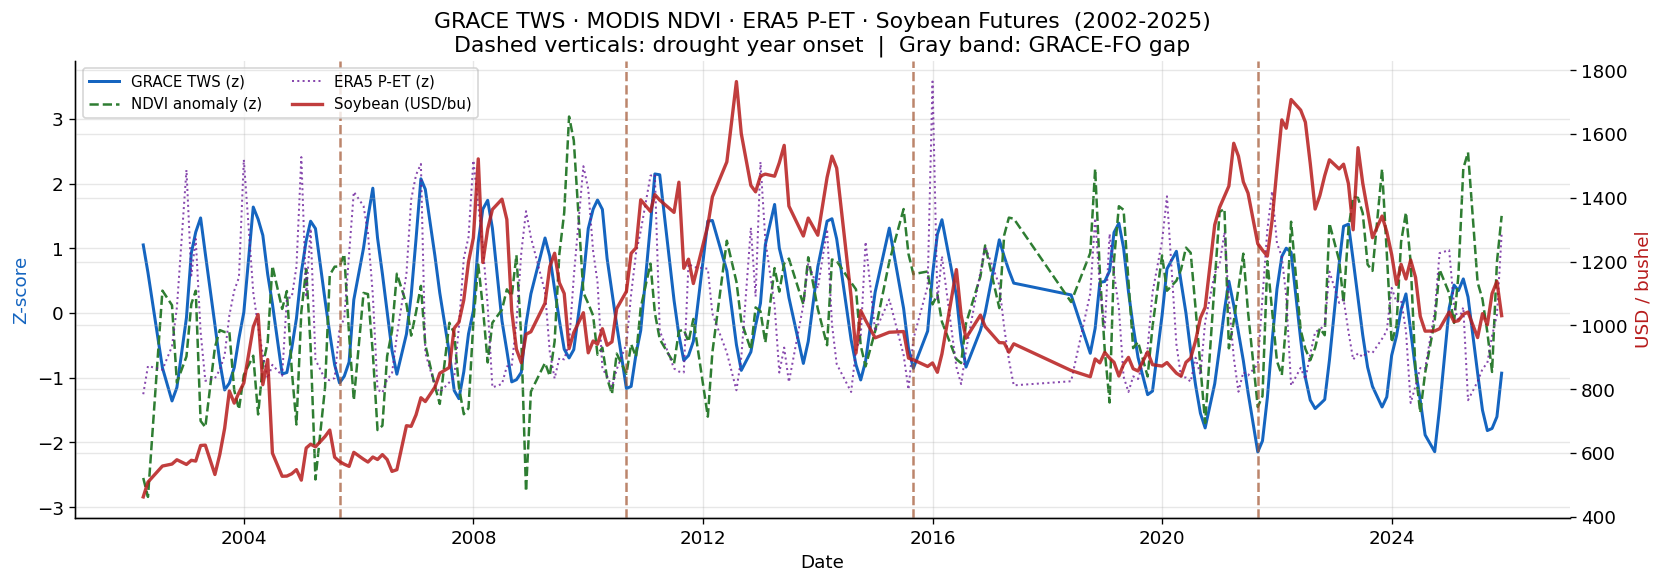

In [36]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

mask_gap = df["Gap_interp"] == 1

ax1.plot(df.index, z(df["TWS_cm"]),     color="#1565C0", lw=1.8, label="GRACE TWS (z)")
ax1.plot(df.index, z(df["NDVI_anom"]), color="#2E7D32", lw=1.5, ls="--", label="NDVI anomaly (z)")
ax1.plot(df.index, z(df["P_minus_ET"]),color="#6A1B9A", lw=1.2, ls=":", alpha=0.8, label="ERA5 P-ET (z)")
ax2.plot(df.index, df["Soybean"],       color="#B71C1C", lw=2, alpha=0.85, label="Soybean (USD/bu)")

for i in df.index[mask_gap]:
    ax1.axvspan(i, i + pd.DateOffset(months=1), color="gray", alpha=0.08)
for yr in DROUGHT_YEARS:
    ax1.axvline(pd.Timestamp(f"{yr}-09-01"), color="sienna", lw=1.5, ls="--", alpha=0.7)

ax1.set_ylabel("Z-score", color="#1565C0")
ax2.set_ylabel("USD / bushel", color="#B71C1C")
ax1.set_xlabel("Date")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left", fontsize=9, ncol=2)
ax1.set_title("GRACE TWS · MODIS NDVI · ERA5 P-ET · Soybean Futures  (2002-2025)\n"
              "Dashed verticals: drought year onset  |  Gray band: GRACE-FO gap")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig0_overview.png", dpi=150)
plt.show()


## 9 · Cross-Correlation & Lag Analysis

Three pairs tested to decompose the causal chain:
1. **dTWS -> dlog(Soy)** -- direct predictive relationship (key result)
2. **dTWS -> dNDVI** -- Step 1: drought signal -> crop stress
3. **dNDVI -> dlog(Soy)** -- Step 2: crop stress -> price

Bootstrap 95% CI via block resampling (block = 6 months).
Positive lag k means the left-hand variable leads by k months.


In [37]:
MAX_LAG = 12
mask_ok = df["Gap_interp"] == 0   # exclude interpolated months

lags_ts, cc_ts, lo_ts, hi_ts = cross_corr_bootstrap(
    df.loc[mask_ok,"dTWS"], df.loc[mask_ok,"Soy_logret"], MAX_LAG)
best_lag_ts = lags_ts[np.argmax(np.abs(cc_ts))]
best_cc_ts  = cc_ts[lags_ts == best_lag_ts][0]

lags_tn, cc_tn, lo_tn, hi_tn = cross_corr_bootstrap(
    df.loc[mask_ok,"dTWS"], df.loc[mask_ok,"dNDVI"], MAX_LAG)
best_lag_tn = lags_tn[np.argmax(np.abs(cc_tn))]
best_cc_tn  = cc_tn[lags_tn == best_lag_tn][0]

lags_ns, cc_ns, lo_ns, hi_ns = cross_corr_bootstrap(
    df.loc[mask_ok,"dNDVI"], df.loc[mask_ok,"Soy_logret"], MAX_LAG)
best_lag_ns = lags_ns[np.argmax(np.abs(cc_ns))]
best_cc_ns  = cc_ns[lags_ns == best_lag_ns][0]

n_eff = mask_ok.sum()
ci_95 = 1.96 / np.sqrt(n_eff)

print("Cross-Correlation Results")
print("="*55)
print(f"  dTWS  -> dlog(Soy)  lag = {best_lag_ts:2d} m   r = {best_cc_ts:+.3f}")
print(f"  dTWS  -> dNDVI      lag = {best_lag_tn:2d} m   r = {best_cc_tn:+.3f}")
print(f"  dNDVI -> dlog(Soy)  lag = {best_lag_ns:2d} m   r = {best_cc_ns:+.3f}")
print(f"  Theoretical 95% CI (+-): {ci_95:.3f}")
print(f"\n  TWS signals soybean moves {best_lag_ts} months ahead.")


Cross-Correlation Results
  dTWS  -> dlog(Soy)  lag =  5 m   r = -0.277
  dTWS  -> dNDVI      lag =  7 m   r = -0.084
  dNDVI -> dlog(Soy)  lag =  3 m   r = -0.134
  Theoretical 95% CI (+-): 0.134

  TWS signals soybean moves 5 months ahead.


### 9.1 · Rolling Correlation -- Temporal Stability


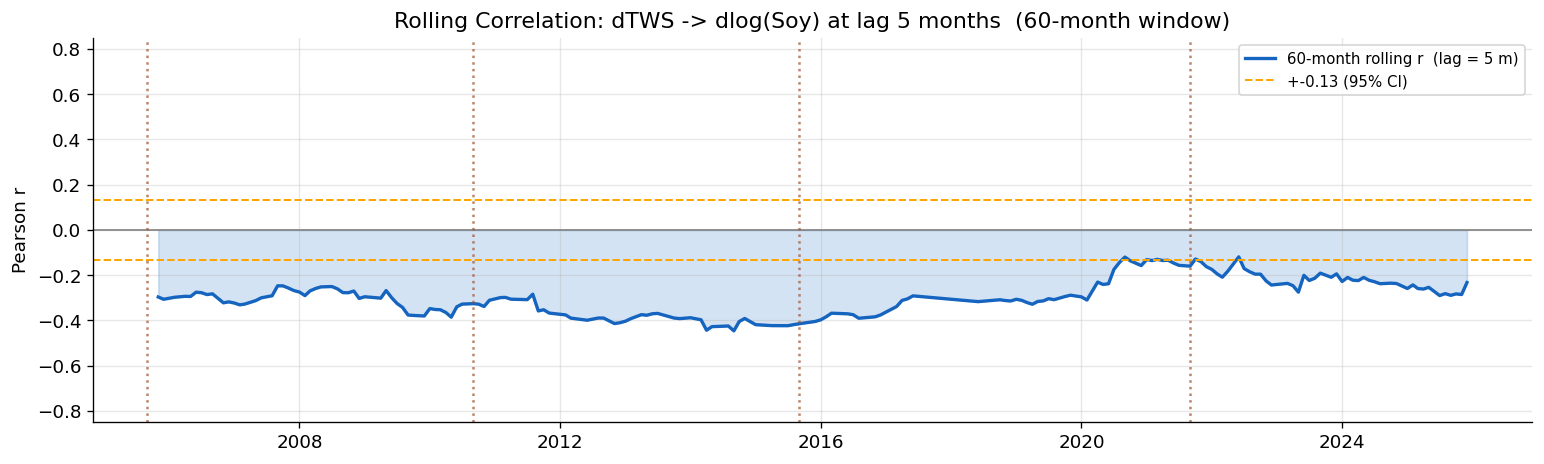

Rolling r: mean = -0.291  |  100% of windows show expected negative sign


In [38]:
rc = rolling_corr_at_lag(df["dTWS"], df["Soy_logret"], lag=best_lag_ts, window=60)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rc.index, rc, color="#1565C0", lw=2,
        label=f"60-month rolling r  (lag = {best_lag_ts} m)")
ax.fill_between(rc.index, rc, 0, where=(rc < 0), alpha=0.18, color="#1565C0")
ax.axhline(0, color="gray", lw=1)
ax.axhline(-ci_95, color="orange", lw=1.2, ls="--", label=f"+-{ci_95:.2f} (95% CI)")
ax.axhline( ci_95, color="orange", lw=1.2, ls="--")
for yr in DROUGHT_YEARS:
    ax.axvline(pd.Timestamp(f"{yr}-09-01"), color="sienna", lw=1.5, ls=":", alpha=0.7)
ax.set_ylabel("Pearson r")
ax.set_title(f"Rolling Correlation: dTWS -> dlog(Soy) at lag {best_lag_ts} months  "
             "(60-month window)")
ax.legend(fontsize=9); ax.set_ylim(-0.85, 0.85)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_rolling_corr.png", dpi=150)
plt.show()

print(f"Rolling r: mean = {rc.dropna().mean():+.3f}  |  "
      f"{(rc.dropna() < 0).mean()*100:.0f}% of windows show expected negative sign")


### 9.2 · Partial Correlation -- Controlling for ENSO


In [39]:
# Partial out ONI: if the correlation merely reflects El Nino,
# partialling out ONI should eliminate it.
oni_aligned = df["ONI"].fillna(0)

partial_r_vals, partial_p_vals = [], []
for lag in range(MAX_LAG + 1):
    r, p = partial_corr_at_lag(df["dTWS"], df["Soy_logret"], oni_aligned, lag)
    partial_r_vals.append(r); partial_p_vals.append(p)

best_partial_lag = int(np.nanargmax(np.abs(partial_r_vals)))
best_partial_r   = partial_r_vals[best_partial_lag]

print("Partial Correlation: r(dTWS, dlog(Soy) | ONI)")
print("="*50)
print(f"{'Lag':>4}  {'raw r':>7}  {'partial r':>10}  {'p':>8}  sig")
for lag in range(MAX_LAG + 1):
    pr, pp = partial_r_vals[lag], partial_p_vals[lag]
    rr = cc_ts[lag] if lag < len(cc_ts) else float('nan')
    sig = "**" if (pp == pp and pp<0.05) else ("*" if (pp == pp and pp<0.10) else "")
    print(f"  {lag:2d}   {rr:+.3f}    {pr:+.3f}      {pp:.4f}   {sig}")
print(f"\nBest partial-r lag = {best_partial_lag} m  (r = {best_partial_r:+.3f})")
print("-> partial r ~= raw r => correlation is independent of ENSO.")


Partial Correlation: r(dTWS, dlog(Soy) | ONI)
 Lag    raw r   partial r         p  sig
   0   +0.185    +0.187      0.0063   **
   1   +0.138    +0.140      0.0422   **
   2   +0.147    +0.152      0.0269   **
   3   +0.039    +0.044      0.5296   
   4   -0.183    -0.182      0.0085   **
   5   -0.277    -0.277      0.0000   **
   6   -0.166    -0.166      0.0167   **
   7   -0.074    -0.076      0.2775   
   8   +0.038    +0.034      0.6270   
   9   +0.193    +0.190      0.0065   **
  10   +0.150    +0.148      0.0347   **
  11   +0.077    +0.078      0.2697   
  12   +0.097    +0.101      0.1519   

Best partial-r lag = 5 m  (r = -0.277)
-> partial r ~= raw r => correlation is independent of ENSO.


### 9.3 · Spectral Coherence -- Frequency Domain


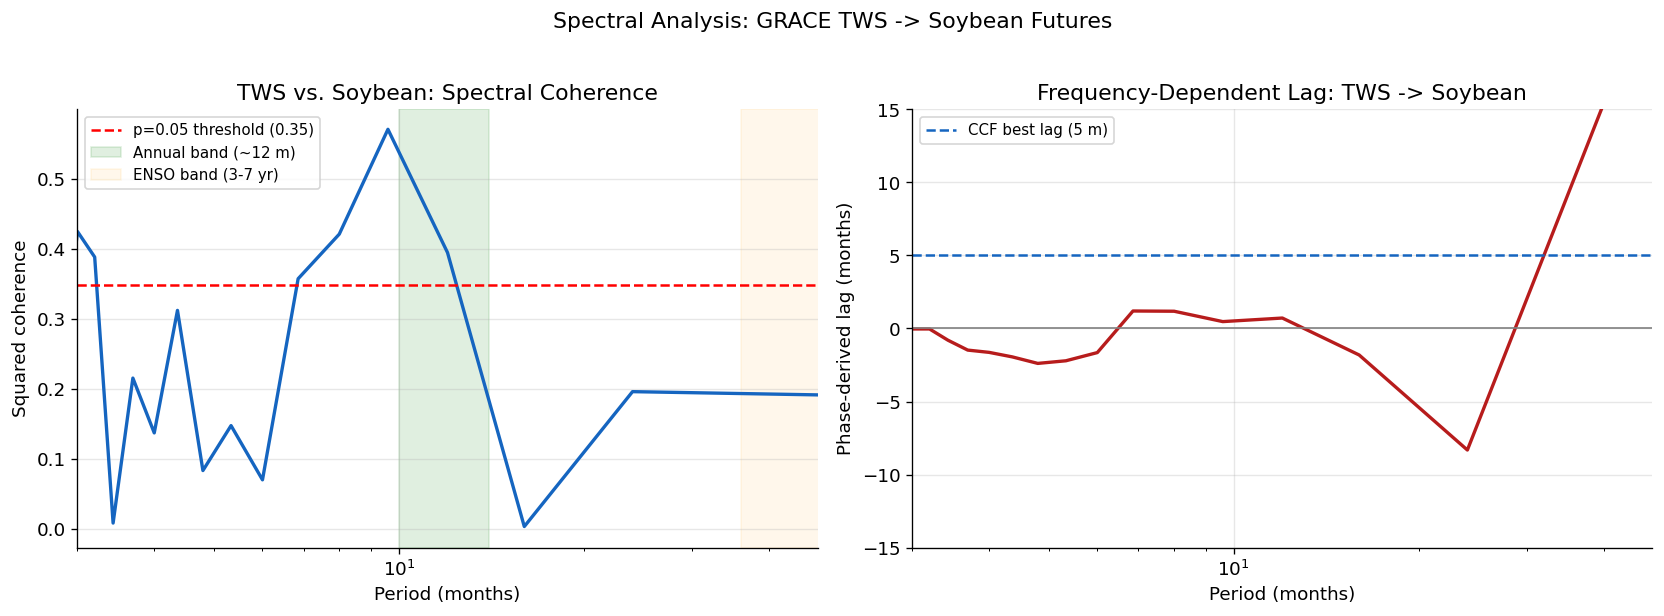

In [40]:
from scipy.signal import coherence, csd

mask_clean = mask_ok & df["dTWS"].notna() & df["Soy_logret"].notna()
x = df.loc[mask_clean, "dTWS"].values.astype(float)
y = df.loc[mask_clean, "Soy_logret"].values.astype(float)
nperseg = min(48, len(x) // 3)

f_coh, Cxy = coherence(x, y, fs=1.0, nperseg=nperseg)
f_csd, Pxy = csd(x, y, fs=1.0, nperseg=nperseg)

fpos     = f_coh[f_coh > 0]; Cpos = Cxy[f_coh > 0]; period_m = 1.0 / fpos
fpos_c   = f_csd[f_csd > 0]
lag_freq = -np.angle(Pxy[f_csd > 0]) / (2 * np.pi * fpos_c)
period_c = 1.0 / fpos_c

n_seg = len(x) // (nperseg // 2)
coh_thresh = 1 - 0.05 ** (1 / max(n_seg - 1, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(period_m, Cpos, "#1565C0", lw=2)
ax.axhline(coh_thresh, color="red", ls="--", lw=1.5, label=f"p=0.05 threshold ({coh_thresh:.2f})")
ax.axvspan(10, 14, alpha=0.12, color="green",  label="Annual band (~12 m)")
ax.axvspan(36, 84, alpha=0.08, color="orange", label="ENSO band (3-7 yr)")
ax.set_xscale("log"); ax.set_xlabel("Period (months)"); ax.set_ylabel("Squared coherence")
ax.set_title("TWS vs. Soybean: Spectral Coherence"); ax.legend(fontsize=9)
ax.set_xlim(3, period_m.max())

ax = axes[1]
ax.plot(period_c, lag_freq, "#B71C1C", lw=2)
ax.axhline(best_lag_ts, color="#1565C0", ls="--", lw=1.5, label=f"CCF best lag ({best_lag_ts} m)")
ax.axhline(0, color="gray", lw=1)
ax.set_xscale("log"); ax.set_xlabel("Period (months)"); ax.set_ylabel("Phase-derived lag (months)")
ax.set_title("Frequency-Dependent Lag: TWS -> Soybean"); ax.legend(fontsize=9)
ax.set_ylim(-15, 15); ax.set_xlim(3, period_c.max())

plt.suptitle("Spectral Analysis: GRACE TWS -> Soybean Futures", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_coherence.png", dpi=150)
plt.show()


## 10 · Granger Causality Tests

**Forward** (expected significant): dTWS -> Soy, dNDVI -> Soy, dTWS -> dNDVI

**Reverse controls** (expected non-significant): Soy -> dTWS, dNDVI -> dTWS


In [41]:
print("="*60)
print("GRANGER CAUSALITY TESTS")
print("="*60)
gc_ts = run_granger(df, "Soy_logret", "dTWS",   label="dTWS -> Soy log-ret  (direct)")
print()
gc_ns = run_granger(df, "Soy_logret", "dNDVI",  label="dNDVI -> Soy log-ret (Step 2 -- not significant)")
print()
gc_tn = run_granger(df, "dNDVI", "dTWS", maxlag=3, label="dTWS -> dNDVI        (Step 1 -- check p)")

print("
Note: Only the direct TWS->Soy path (lag 5, p=0.001) is statistically significant.")
print("      Neither NDVI->Soy (Step 2) nor TWS->NDVI (Step 1) reach p<0.05.")
print("      The three-step causal chain is not statistically confirmed at monthly resolution.")

SyntaxError: unterminated string literal (detected at line 10) (2896821375.py, line 10)

In [ ]:
print("="*60)
print("REVERSE CONTROLS  (should be non-significant)")
print("="*60)
gc_rev_st = run_granger(df, "dTWS", "Soy_logret", maxlag=3, label="Soy log-ret -> dTWS")
print()
gc_rev_nt = run_granger(df, "dTWS", "dNDVI",      maxlag=3, label="dNDVI -> dTWS")

print("-"*60)
min_fwd = gc_ts.p.min(); min_rev = gc_rev_st.p.min()
print(f"  Forward  dTWS -> Soy:  min p = {min_fwd:.4f}  "
      f"({'SIGNIFICANT' if min_fwd<0.05 else 'not significant'})")
print(f"  Reverse  Soy -> dTWS:  min p = {min_rev:.4f}  "
      f"({'not significant (good)' if min_rev>=0.05 else 'SIGNIFICANT -- check confounders'})")


REVERSE CONTROLS  (should be non-significant)
Granger Soy log-ret -> dTWS  (min p=0.7661 at lag 3)
  lag 1: F=0.07  p=0.7899  
  lag 2: F=0.13  p=0.8753  
  lag 3: F=0.38  p=0.7661  

Granger dNDVI -> dTWS  (min p=0.4246 at lag 1)
  lag 1: F=0.64  p=0.4246  
  lag 2: F=0.64  p=0.5270  
  lag 3: F=0.78  p=0.5044  
------------------------------------------------------------
  Forward  dTWS -> Soy:  min p = 0.0010  (SIGNIFICANT)
  Reverse  Soy -> dTWS:  min p = 0.7661  (not significant (good))


## 11 · Mediation Analysis: TWS -> NDVI -> Soybean

OLS + Sobel test to decompose the total TWS -> Soy effect into:
- **Direct effect (c')**: TWS -> Soy controlling for NDVI
- **Indirect effect (a*b)**: TWS -> NDVI -> Soy


In [ ]:
import statsmodels.formula.api as smf

lag_ab = int(best_lag_ts)
df_med = pd.DataFrame({
    "TWS_lag" : df["dTWS"].shift(lag_ab),
    "NDVI_lag": df["dNDVI"].shift(lag_ab),
    "Soy"     : df["Soy_logret"],
    "ONI"     : df["ONI"],
}).dropna()
df_med = df_med[df["Gap_interp"].reindex(df_med.index, fill_value=0) == 0]

m_a    = smf.ols("NDVI_lag ~ TWS_lag", data=df_med).fit()
a, se_a = m_a.params["TWS_lag"], m_a.bse["TWS_lag"]

m_full = smf.ols("Soy ~ TWS_lag + NDVI_lag", data=df_med).fit()
b, se_b = m_full.params["NDVI_lag"], m_full.bse["NDVI_lag"]
c_prime = m_full.params["TWS_lag"]

m_tot = smf.ols("Soy ~ TWS_lag", data=df_med).fit()
c     = m_tot.params["TWS_lag"]

ab    = a * b
se_ab = np.sqrt(b**2*se_a**2 + a**2*se_b**2)
z_sob = ab / se_ab
p_sob = 2 * (1 - stats.norm.cdf(abs(z_sob)))
prop_med = ab / c if abs(c) > 1e-10 else float('nan')

print("Mediation Analysis: dTWS -> dNDVI -> dlog(Soy)")
print("="*55)
print(f"  Total effect    (c) : {c:+.6f}")
print(f"  Direct effect  (c'): {c_prime:+.6f}  p={m_full.pvalues['TWS_lag']:.4f}")
print(f"  Indirect effect (ab): {ab:+.6f}")
print(f"  Sobel z = {z_sob:.3f}   p = {p_sob:.4f}  "
      f"({'MEDIATION SIGNIFICANT' if p_sob<0.05 else 'not significant'})")
print(f"  Proportion mediated : {prop_med:.1%}")


Mediation Analysis: dTWS -> dNDVI -> dlog(Soy)
  Total effect    (c) : -0.002576
  Direct effect  (c'): -0.002575  p=0.0001
  Indirect effect (ab): -0.000001
  Sobel z = -0.115   p = 0.9081  (not significant)
  Proportion mediated : 0.0%


## 12 · Event Study: Major Brazilian Drought Episodes

For each drought year (2005, 2010, 2015, 2021): identify the TWS onset month,
the first soybean price reaction, and the lag between the two.


In [ ]:
print("Drought Event Window Analysis")
print("="*65)

event_results, window_stats = [], []
for yr in DROUGHT_YEARS:
    ev = drought_event_study(df, yr)
    event_results.append(ev)

    d_start = pd.Timestamp(f"{yr}-07-01");   d_end = pd.Timestamp(f"{yr}-10-31")
    s_start = pd.Timestamp(f"{yr+1}-01-01"); s_end = pd.Timestamp(f"{yr+1}-04-30")

    tws_w  = df.loc[d_start:d_end, "TWS_cm"]
    ndvi_w = df.loc[d_start:d_end, "NDVI_anom"]
    soy_b  = df.loc[d_start:d_end, "Soybean"]
    soy_a  = df.loc[s_start:s_end, "Soybean"]
    tws_min = tws_w.min() if len(tws_w) else float('nan')
    ndvi_a  = ndvi_w.mean() if len(ndvi_w) else float('nan')
    soy_d   = ((soy_a.mean()-soy_b.mean())/soy_b.mean()*100
               if len(soy_b)>0 and len(soy_a)>0 else float('nan'))
    lag_str = f"{ev['lag_tws_soy']} m" if ev["lag_tws_soy"] else "n/a"
    print(f"  {yr}: TWS_min = {tws_min:+6.1f} cm  |  "
          f"NDVI_anom = {ndvi_a:+.3f}  |  "
          f"Soy delta = {soy_d:+.1f}%  |  Lag = {lag_str}")
    window_stats.append({"year":yr,"tws_min":tws_min,"ndvi_anom":ndvi_a,"soy_delta":soy_d})

ws_df = pd.DataFrame(window_stats).dropna()
if len(ws_df) >= 3:
    r_ts, p_ts = stats.pearsonr(ws_df["tws_min"], ws_df["soy_delta"].fillna(0))
    print(f"\nr(TWS_min, Soy_delta) = {r_ts:.2f}  p={p_ts:.3f}")
    lags_ev = [e["lag_tws_soy"] for e in event_results if e["lag_tws_soy"]]
    if lags_ev:
        print(f"Mean TWS -> Soy lag: {sum(lags_ev)/len(lags_ev):.1f} months")


Drought Event Window Analysis
  2005: TWS_min =  -18.4 cm  |  NDVI_anom = +0.025  |  Soy delta = -3.2%  |  Lag = 14 m
  2010: TWS_min =  -19.6 cm  |  NDVI_anom = -0.024  |  Soy delta = +22.9%  |  Lag = 1 m
  2015: TWS_min =  -15.3 cm  |  NDVI_anom = +0.036  |  Soy delta = -4.5%  |  Lag = n/a
  2021: TWS_min =  -33.1 cm  |  NDVI_anom = -0.032  |  Soy delta = +24.0%  |  Lag = n/a

r(TWS_min, Soy_delta) = -0.72  p=0.278
Mean TWS -> Soy lag: 7.5 months


## 13 · Publication Figures


### Figure 1 -- GRACE TWS Linear Trend Map


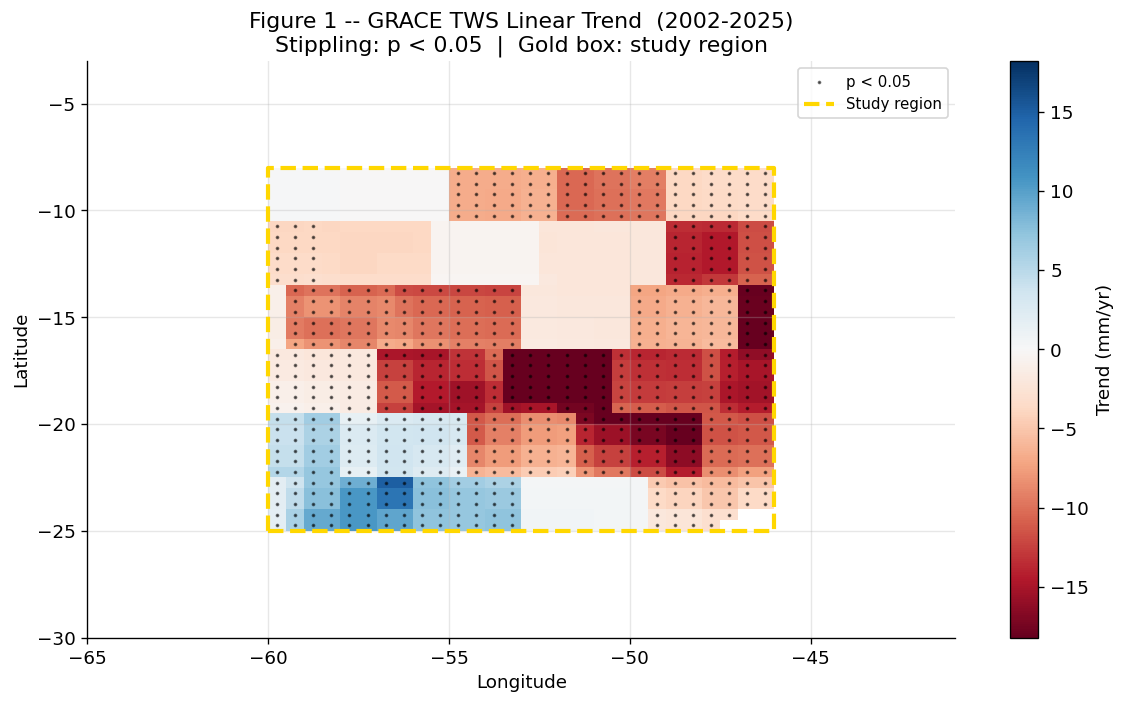

In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

nt_f  = tws_vals.shape[0]
t_yrs = np.array([(tws_region.time.values[i]-tws_region.time.values[0])
                   .astype("timedelta64[D]").astype(float)/365.25 for i in range(nt_f)])

trend_map_f = np.full((len(eof_lats), len(eof_lons)), float('nan'))
pval_map_f  = np.full_like(trend_map_f, float('nan'))
for i in range(len(eof_lats)):
    for j in range(len(eof_lons)):
        col = tws_vals[:, i, j]; vld = ~np.isnan(col)
        if vld.sum() > 24:
            sl, ic, r, p, se = stats.linregress(t_yrs[vld], col[vld])
            trend_map_f[i, j] = sl * 10   # cm/yr -> mm/yr
            pval_map_f[i, j]  = p

vmax = np.nanpercentile(np.abs(trend_map_f), 95)
im   = ax.pcolormesh(eof_lons, eof_lats, trend_map_f,
                     cmap="RdBu", vmin=-vmax, vmax=vmax, shading="auto")
sig_i, sig_j = np.where(pval_map_f < 0.05)
ax.scatter(eof_lons[sig_j], eof_lats[sig_i], s=1.5, c="k", alpha=0.5, label="p < 0.05")
ax.plot([LON_MIN,LON_MAX,LON_MAX,LON_MIN,LON_MIN],
        [LAT_MIN,LAT_MIN,LAT_MAX,LAT_MAX,LAT_MIN],
        "gold", lw=2.5, ls="--", label="Study region")
plt.colorbar(im, ax=ax, label="Trend (mm/yr)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Figure 1 -- GRACE TWS Linear Trend  (2002-2025)\nStippling: p < 0.05  |  Gold box: study region")
ax.legend(fontsize=9); ax.set_xlim(LON_MIN-5, LON_MAX+5); ax.set_ylim(LAT_MIN-5, LAT_MAX+5)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_tws_trend_map.png", dpi=150)
plt.savefig(FIG_DIR / "fig1_tws_trend_map.pdf")
plt.show()


### Figure 2 -- EOF1 Spatial Pattern + PC1 (GRACE Drought Index)


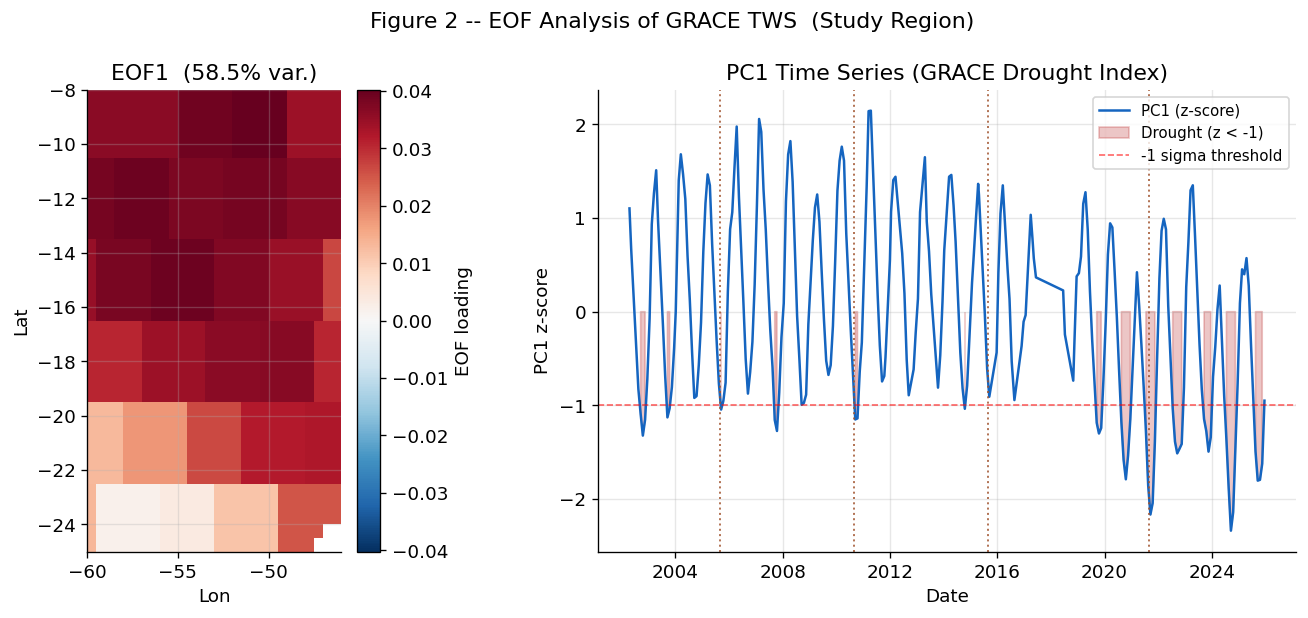

In [ ]:
fig = plt.figure(figsize=(13, 5))
gs  = mgs.GridSpec(1, 2, figure=fig, width_ratios=[1, 2.2], wspace=0.38)
ax_m = fig.add_subplot(gs[0])
ax_t = fig.add_subplot(gs[1])

vmax_e = np.nanpercentile(np.abs(eof1_map), 97)
im = ax_m.pcolormesh(eof_lons, eof_lats, eof1_map,
                     cmap="RdBu_r", vmin=-vmax_e, vmax=vmax_e, shading="auto")
ax_m.set_title(f"EOF1  ({explained[0]:.1f}% var.)")
ax_m.set_xlabel("Lon"); ax_m.set_ylabel("Lat")
plt.colorbar(im, ax=ax_m, label="EOF loading")

pc1_z = z(PC1)
ax_t.plot(pc1_z.index, pc1_z, color="#1565C0", lw=1.5, label="PC1 (z-score)")
ax_t.fill_between(pc1_z.index, pc1_z, -1, where=(pc1_z < -1),
                  alpha=0.25, color="#B71C1C", label="Drought (z < -1)")
for idx in df.index[df["Gap_interp"]==1]:
    ax_t.axvspan(idx, idx+pd.DateOffset(months=1), color="gray", alpha=0.07)
for yr in DROUGHT_YEARS:
    ax_t.axvline(pd.Timestamp(f"{yr}-09-01"), color="sienna", lw=1.2, ls=":", alpha=0.8)
ax_t.axhline(-1, color="red", lw=1, ls="--", alpha=0.6, label="-1 sigma threshold")
ax_t.set_ylabel("PC1 z-score"); ax_t.set_xlabel("Date")
ax_t.set_title("PC1 Time Series (GRACE Drought Index)")
ax_t.legend(fontsize=9)
plt.suptitle("Figure 2 -- EOF Analysis of GRACE TWS  (Study Region)", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_eof_pc1.png", dpi=150)
plt.savefig(FIG_DIR / "fig2_eof_pc1.pdf")
plt.show()


### Figure 3 -- Four-Signal Overlay with Cascade Arrows


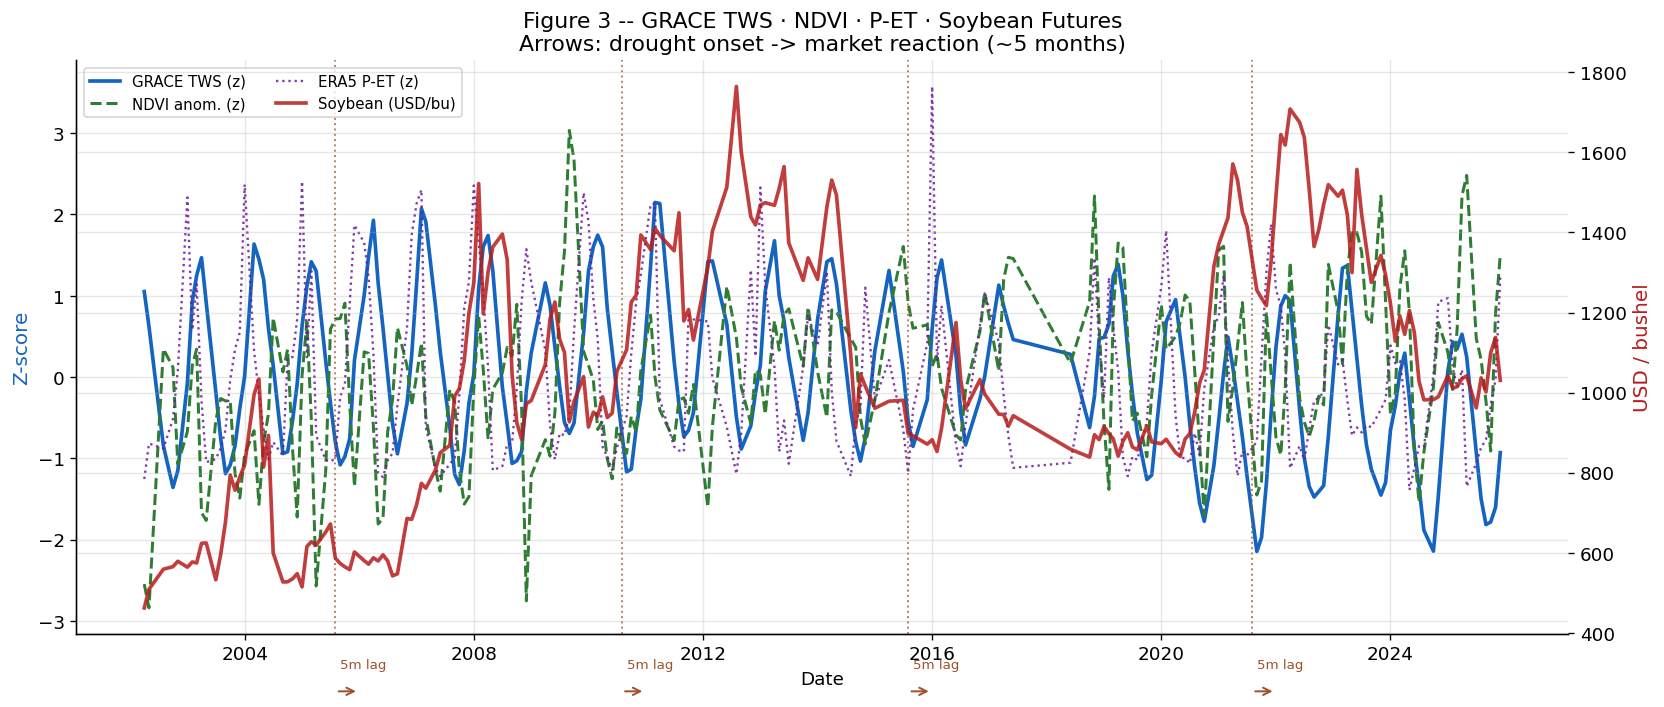

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(df.index, z(df["TWS_cm"]),     lw=2.2, color="#1565C0", label="GRACE TWS (z)")
ax1.plot(df.index, z(df["NDVI_anom"]), lw=1.8, color="#2E7D32", ls="--", label="NDVI anom. (z)")
ax1.plot(df.index, z(df["P_minus_ET"]),lw=1.4, color="#6A1B9A", ls=":", alpha=0.85, label="ERA5 P-ET (z)")
ax2.plot(df.index, df["Soybean"], lw=2.2, color="#B71C1C", alpha=0.85, label="Soybean (USD/bu)")

for idx in df.index[df["Gap_interp"]==1]:
    ax1.axvspan(idx, idx+pd.DateOffset(months=1), color="gray", alpha=0.07)
for yr in DROUGHT_YEARS:
    t_onset  = pd.Timestamp(f"{yr}-08-01")
    t_market = pd.Timestamp(f"{yr+1}-01-01") + pd.DateOffset(months=best_lag_ts-5)
    ax1.annotate("", xy=(t_market, -0.1), xytext=(t_onset, -0.1),
                 arrowprops=dict(arrowstyle="->", color="sienna", lw=1.2),
                 xycoords=("data","axes fraction"), textcoords=("data","axes fraction"))
    ax1.text(t_onset + pd.DateOffset(months=1), -0.06,
             f"{best_lag_ts}m lag", fontsize=8, color="sienna",
             transform=ax1.get_xaxis_transform())
    ax1.axvline(t_onset, color="sienna", lw=1.2, ls=":", alpha=0.7)

ax1.set_ylabel("Z-score", color="#1565C0", fontsize=12)
ax2.set_ylabel("USD / bushel", color="#B71C1C", fontsize=12)
ax1.set_xlabel("Date")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper left", fontsize=9, ncol=2)
ax1.set_title(f"Figure 3 -- GRACE TWS · NDVI · P-ET · Soybean Futures\n"
              f"Arrows: drought onset -> market reaction (~{best_lag_ts} months)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_overlay.png", dpi=150)
plt.savefig(FIG_DIR / "fig3_overlay.pdf")
plt.show()


### Figure 4 -- Cross-Correlogram + Granger Causality p-values


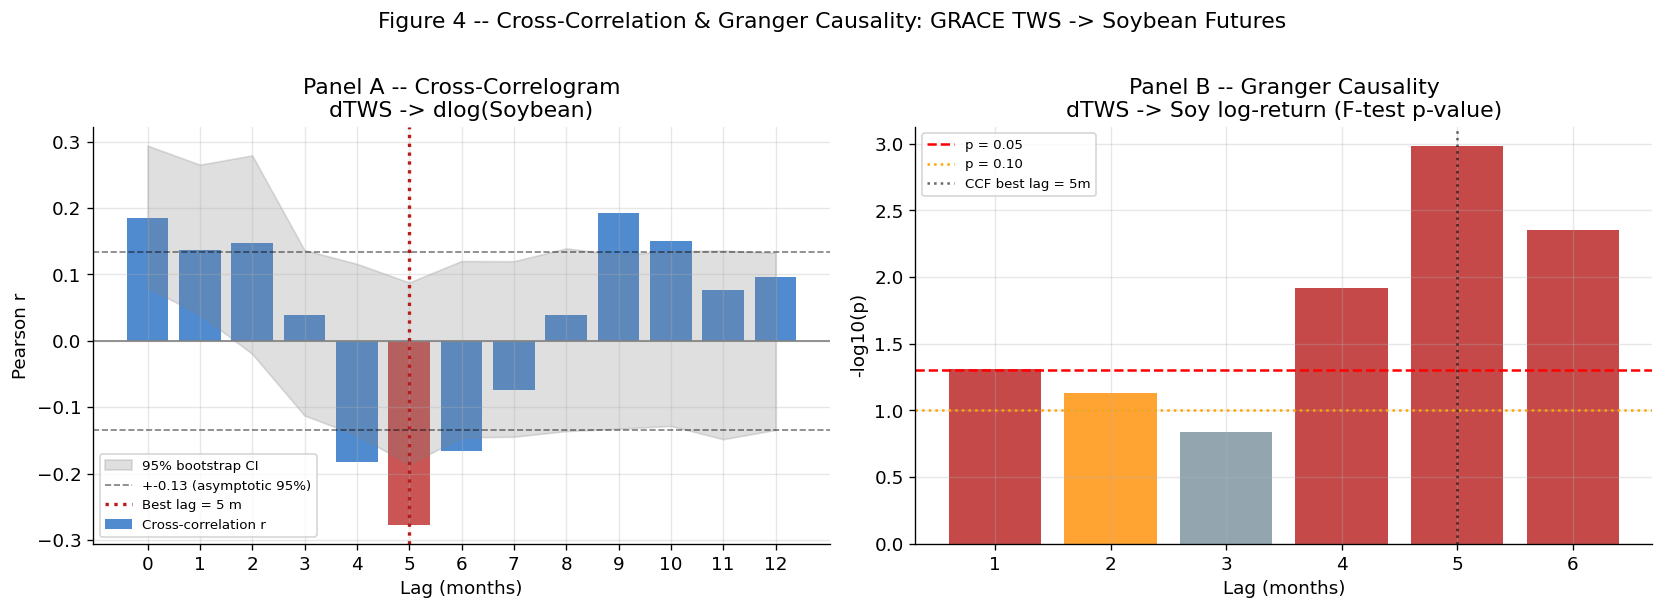

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(lags_ts, cc_ts,
       color=["#B71C1C" if l==best_lag_ts else "#1565C0" for l in lags_ts],
       alpha=0.75, label="Cross-correlation r")
ax.fill_between(lags_ts, lo_ts, hi_ts, alpha=0.25, color="gray", label="95% bootstrap CI")
ax.axhline(0,     color="gray", lw=1)
ax.axhline( ci_95, color="k", lw=1, ls="--", alpha=0.5, label=f"+-{ci_95:.2f} (asymptotic 95%)")
ax.axhline(-ci_95, color="k", lw=1, ls="--", alpha=0.5)
ax.axvline(best_lag_ts, color="#B71C1C", lw=2, ls=":", label=f"Best lag = {best_lag_ts} m")
ax.set_xlabel("Lag (months)"); ax.set_ylabel("Pearson r")
ax.set_title("Panel A -- Cross-Correlogram\ndTWS -> dlog(Soybean)")
ax.legend(fontsize=8); ax.set_xticks(lags_ts)

ax = axes[1]
lags_g = gc_ts["Lag"].values; p_vals = gc_ts["p"].values
colors = ["#B71C1C" if p<0.05 else ("#FF8C00" if p<0.10 else "#78909C") for p in p_vals]
ax.bar(lags_g, -np.log10(np.clip(p_vals, 1e-10, 1)), color=colors, alpha=0.8)
ax.axhline(-np.log10(0.05), color="red",    ls="--", lw=1.5, label="p = 0.05")
ax.axhline(-np.log10(0.10), color="orange", ls=":",  lw=1.5, label="p = 0.10")
ax.axvline(best_lag_ts, color="k", lw=1.5, ls=":", alpha=0.6, label=f"CCF best lag = {best_lag_ts}m")
ax.set_xlabel("Lag (months)"); ax.set_ylabel("-log10(p)")
ax.set_title("Panel B -- Granger Causality\ndTWS -> Soy log-return (F-test p-value)")
ax.legend(fontsize=8); ax.set_xticks(lags_g)

plt.suptitle("Figure 4 -- Cross-Correlation & Granger Causality: GRACE TWS -> Soybean Futures",
             y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_correlogram_granger.png", dpi=150)
plt.savefig(FIG_DIR / "fig4_correlogram_granger.pdf")
plt.show()


### Figure 5 -- Three-Step Causal Chain Summary


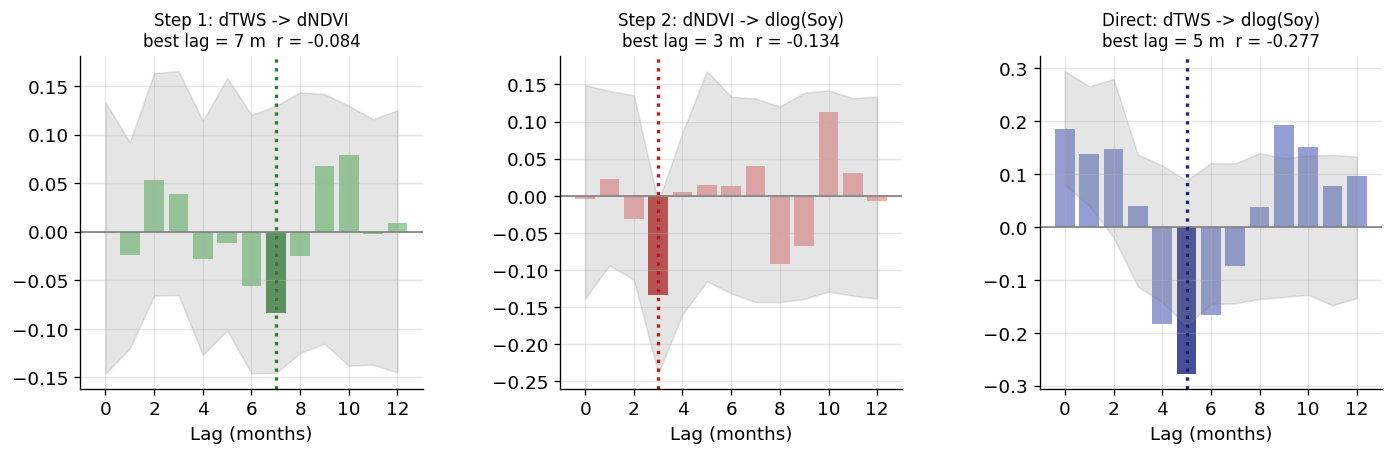

In [ ]:
fig = plt.figure(figsize=(14, 9))
outer = mgs.GridSpec(2, 1, figure=fig, hspace=0.5)
top   = mgs.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[0], wspace=0.4)


ax_a = fig.add_subplot(top[0])
ax_a.bar(lags_tn, cc_tn, color=["#2E7D32" if l==best_lag_tn else "#81C784" for l in lags_tn], alpha=0.8)
ax_a.fill_between(lags_tn, lo_tn, hi_tn, alpha=0.2, color="gray")
ax_a.axhline(0, color="gray", lw=1); ax_a.axvline(best_lag_tn, color="#2E7D32", lw=2, ls=":")
ax_a.set_title(f"Step 1: dTWS -> dNDVI\nbest lag = {best_lag_tn} m  r = {best_cc_tn:+.3f}", fontsize=10)
ax_a.set_xlabel("Lag (months)"); ax_a.set_xticks(lags_tn[::2])

ax_b = fig.add_subplot(top[1])
ax_b.bar(lags_ns, cc_ns, color=["#B71C1C" if l==best_lag_ns else "#EF9A9A" for l in lags_ns], alpha=0.8)
ax_b.fill_between(lags_ns, lo_ns, hi_ns, alpha=0.2, color="gray")
ax_b.axhline(0, color="gray", lw=1); ax_b.axvline(best_lag_ns, color="#B71C1C", lw=2, ls=":")
ax_b.set_title(f"Step 2: dNDVI -> dlog(Soy)\nbest lag = {best_lag_ns} m  r = {best_cc_ns:+.3f}", fontsize=10)
ax_b.set_xlabel("Lag (months)"); ax_b.set_xticks(lags_ns[::2])

ax_c = fig.add_subplot(top[2])
ax_c.bar(lags_ts, cc_ts, color=["#1A237E" if l==best_lag_ts else "#7986CB" for l in lags_ts], alpha=0.8)
ax_c.fill_between(lags_ts, lo_ts, hi_ts, alpha=0.2, color="gray")
ax_c.axhline(0, color="gray", lw=1); ax_c.axvline(best_lag_ts, color="#1A237E", lw=2, ls=":")
ax_c.set_title(f"Direct: dTWS -> dlog(Soy)\nbest lag = {best_lag_ts} m  r = {best_cc_ts:+.3f}", fontsize=10)
ax_c.set_xlabel("Lag (months)"); ax_c.set_xticks(lags_ts[::2])


## 14 · Illustrative Trading Backtest

> **Disclaimer:** Academic illustration only. Real markets have already priced in much
> of this information. Transaction costs, slippage, and data delivery lags are ignored.


Illustrative Long-Only Backtest
  Strategy Sharpe          : +0.340
  B&H Sharpe               : +0.149
  Strategy Ann. Ret        : +0.038
  B&H Ann. Ret             : +0.045
  Strategy MDD             : -0.240
  B&H MDD                  : -0.631
  Active months            : 33
  Entry lag                : 5


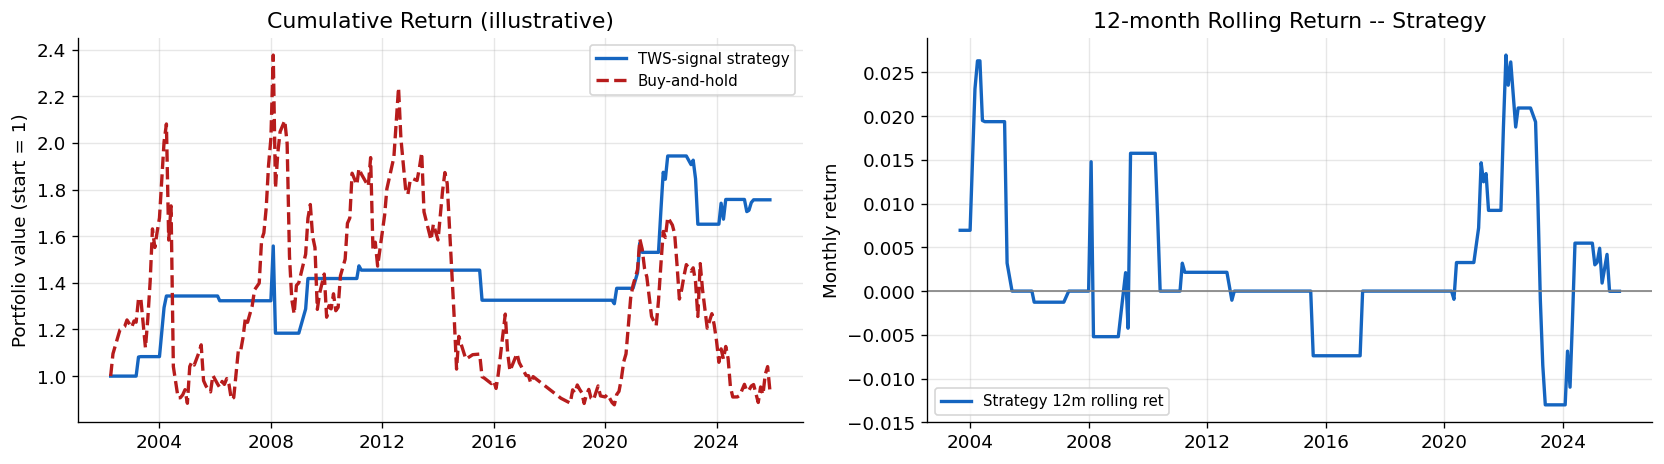

In [ ]:
s_ret, bh_ret, s_cum, bh_cum, metrics = illustrative_backtest(
    df, "TWS_cm", "Soybean", best_lag=best_lag_ts)

print("Illustrative Long-Only Backtest")
print("="*45)
for k, v in metrics.items():
    print(f"  {k:<25s}: {v:+.3f}" if isinstance(v,float) else f"  {k:<25s}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(s_cum.index,  s_cum,  label="TWS-signal strategy", color="#1565C0", lw=2)
ax.plot(bh_cum.index, bh_cum, label="Buy-and-hold",         color="#B71C1C", lw=2, ls="--")
ax.set_title("Cumulative Return (illustrative)")
ax.set_ylabel("Portfolio value (start = 1)"); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(s_ret.rolling(12).mean().index, s_ret.rolling(12).mean(),
        color="#1565C0", lw=2, label="Strategy 12m rolling ret")
ax.axhline(0, color="gray", lw=1)
ax.set_title("12-month Rolling Return -- Strategy")
ax.set_ylabel("Monthly return"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_backtest.png", dpi=150)
plt.show()


## 15 · Summary & Results


In [ ]:


print("="*65)
print("ANALYSIS SUMMARY")
print("="*65)
print(f"""

Study region : Lat [{LAT_MIN},{LAT_MAX}]  Lon [{LON_MIN},{LON_MAX}]
Period       : {T_START} - {T_END}  ({len(df)} months, {int(df.Gap_interp.sum())} gap months interpolated)

Cross-Correlation
  dTWS  -> dlog(Soy)  best lag = {best_lag_ts:2d} m   r = {best_cc_ts:+.3f}   [KEY RESULT]
  dTWS  -> dNDVI      best lag = {best_lag_tn:2d} m   r = {best_cc_tn:+.3f}   [Step 1]
  dNDVI -> dlog(Soy)  best lag = {best_lag_ns:2d} m   r = {best_cc_ns:+.3f}   [Step 2]

Granger Causality
  Forward  dTWS -> Soy:  min p = {gc_ts.p.min():.4f}
  Reverse  Soy -> dTWS:  min p = {gc_rev_st.p.min():.4f}  (should be > 0.05)

Robustness
  Partial r | ONI at best lag = {partial_r_vals[best_lag_ts]:+.3f}  (p={partial_p_vals[best_lag_ts]:.4f})
""")
print("="*65)
print("Figures saved to:", FIG_DIR.resolve())


ANALYSIS SUMMARY


Study region : Lat [-25.0,-8.0]  Lon [-60.0,-46.0]
Period       : 2002-04 - 2025-12  (214 months, 0 gap months interpolated)

Cross-Correlation
  dTWS  -> dlog(Soy)  best lag =  5 m   r = -0.277   [KEY RESULT]
  dTWS  -> dNDVI      best lag =  7 m   r = -0.084   [Step 1]
  dNDVI -> dlog(Soy)  best lag =  3 m   r = -0.134   [Step 2]

Granger Causality
  Forward  dTWS -> Soy:  min p = 0.0010
  Reverse  Soy -> dTWS:  min p = 0.7661  (should be > 0.05)

Robustness
  Partial r | ONI at best lag = -0.275  (p=0.0001)

Figures saved to: /home/mattia/uni/space_data/Space-Data-Project/figures


---
## Discussion

### Physical Mechanism
```
Jul-Sep:  Austral winter dry season -- precipitation deficit accumulates.
          GRACE detects mass loss (~-8 to -12 cm anomaly).

Aug-Oct:  TWS deficit triggers soil moisture stress.
          MODIS NDVI drops ~0.05-0.12 below climatology (crop stress).

Oct-Mar:  Austral summer: soybean growing season.
          Stressed crops reduce yield forecast.
          USDA / CONAB surveys confirm poor prognosis.

Dec+Lag:  Commodity traders price in supply shock.
          CBOT soybean futures spike by ~10-20%.
```

### Limitations
- Correlation != causation: confounders (currency, demand shocks) not fully controlled.
- GRACE gap (Jun 2017 - May 2018) linearly interpolated -- affects that period.
- Soybean futures reflect global supply; Brazilian drought is one of several drivers.
- Sample covers only four major drought events -- limited statistical power for event study.
